In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Part 5: Monitoring & Drift Detection (25 points)


## 5A. Production Data Simulation (5 points)
Create a simulated production dataset by modifying your HW2 training data. Add a month column
(1–6) to track time periods.

1A. Setup and Inference (5 points)

In [2]:
import pandas as pd
import numpy as np

# import Olist dataset - df
df = pd.read_csv('/content/drive/MyDrive/6545_Data_Science_and_ML_Ops/df.csv')


In [3]:
pd.set_option('display.max_columns', None)
display(df.head())

,order_status,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name,prior_review_score_1,prior_review_score_2,payment_value,payment_installments,payment_type,customer_lat,customer_lng,seller_lat,seller_lng,is_negative_review,delivery_days,delivery_days_precise,delivery_vs_estimated,prev_order_count,is_repeat_customer,freight_ratio,product_volume_liters,late_shipping,order_total_items,customer_state_order_count,cust_state_by_n_orders_binned,seller_state_order_count,seller_state_by_n_orders_binned,shipping_dist,prev_product_id_count,product_id_prior_score,prev_seller_id_count,seller_id_prior_score,purchase_to_approval,purchase_to_carrier,purchase_to_estimate,approval_to_carrier,approval_to_customer,approval_to_estimate,carrier_to_customer,carrier_to_estimate,prior_rev_comments
0,delivered,29.99,8.72,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,NaN,NaN,38.71,1.0,"credit_card, voucher",-23.576983,-46.587161,-23.680729,-46.444238,0,8.0,8.4,-8.0,1,1,29.1,1.976,0,1,47449,3,80342,3,19.0,2,4.500000,41,4.463415,0.01,2.37,15.54,2.37,8.43,15.54,6.06,13.17,0
1,delivered,118.70,22.76,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,NaN,NaN,141.46,1.0,boleto,-12.177924,-44.660711,-19.807681,-43.980427,0,14.0,13.8,-6.0,0,0,19.2,4.693,0,1,3799,2,80342,3,847.0,87,4.390805,69,4.594203,1.28,1.74,19.14,0.46,12.50,17.86,12.04,17.40,0
2,delivered,159.90,19.22,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,NaN,NaN,179.12,3.0,credit_card,-16.745150,-48.514783,-21.363502,-48.229601,0,9.0,9.4,-18.0,0,0,12.0,9.576,0,1,2333,2,80342,3,512.0,2,5.000000,1110,4.081081,0.01,0.22,26.64,0.20,9.38,26.63,9.18,26.42,0
3,delivered,45.00,27.20,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,NaN,NaN,72.20,1.0,credit_card,-5.774190,-35.271143,-19.837682,-43.924053,0,14.0,13.2,-13.0,0,0,60.4,6.000,0,1,529,1,8827,2,1816.0,1,3.000000,39,4.384615,0.01,3.76,26.19,3.75,13.20,26.18,9.45,22.43,0
4,delivered,19.90,8.72,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,NaN,NaN,28.62,1.0,credit_card,-23.676370,-46.514627,-23.543395,-46.262086,0,3.0,2.9,-10.0,0,0,43.8,11.475,0,1,47449,3,80342,3,30.0,8,3.750000,52,4.211538,0.04,0.94,12.11,0.89,2.83,12.07,1.94,11.18,0


In [4]:
target_col = 'is_negative_review'
features = [col for col in df.columns if col != target_col]

production_frames = []

# simulate 6 months of data
for month in range(1, 7):
    # sample 3,000 records per month
    sample = df.sample(n=3000, replace=True, random_state=42 + month).copy()

    # add small random noise (±5%) to numeric columns for all months
    for col in features:
        if pd.api.types.is_numeric_dtype(sample[col]):
            noise = np.random.uniform(0.95, 1.05, size=len(sample))
            sample[col] = sample[col] * noise

    # add severe drift for months 4-6
    if month >= 4:
        drift_level = month - 3 # Results in 1, 2, or 3

        # drift 1: delivery_days (+2, +4, +6)
        if 'delivery_days' in sample.columns:
            sample['delivery_days'] += (2 * drift_level)

        # drift 2: freight_value (+15%, +30%, +50%)
        if 'freight_value' in sample.columns:
            multipliers = {4: 1.15, 5: 1.30, 6: 1.50}
            sample['freight_value'] *= multipliers[month]

        # drift 3: order_total_items (increase items per order)
        if 'order_total_items' in sample.columns:
            # Adds 1 extra item in Month 4, 2 in Month 5, 3 in Month 6
            sample['order_total_items'] += drift_level

        # drift 4: ground truth labels (flip 5% positive -> negative)
        pos_idx = sample[sample[target_col] == 1].index
        n_flip = int(len(pos_idx) * 0.05)
        if n_flip > 0:
            flip_idx = np.random.choice(pos_idx, size=n_flip, replace=False)
            sample.loc[flip_idx, target_col] = 0

    sample['month'] = month
    production_frames.append(sample)

# combine all months into one dataset
production_df = pd.concat(production_frames, ignore_index=True)

# delivery days
print(f"Total simulated records: {len(production_df)}")
print("\nAverage Delivery Days per month:")
print(production_df.groupby('month')['delivery_days'].mean())

# freight value
print(f"Total simulated records: {len(production_df)}")
print("\nAverage Freight Value each month:")
print(production_df.groupby('month')['freight_value'].mean())

# product category name
print(f"Total simulated records: {len(production_df)}")
print("\nAverage Order Total Items per month:")
print(production_df.groupby('month')['order_total_items'].mean())

# ground truth labels
print(f"Total simulated records: {len(production_df)}")
print("\nAverage Negative Reviews per month:")
print(production_df.groupby('month')[target_col].mean())

Total simulated records: 18000

Average Delivery Days per month:
month
1    12.350905
2    12.377299
3    12.402316
4    14.887858
5    16.238287
6    18.393600
Name: delivery_days, dtype: float64
Total simulated records: 18000

Average Freight Value each month:
month
1    20.353844
2    20.065684
3    20.020653
4    23.183398
5    26.192179
6    30.547242
Name: freight_value, dtype: float64
Total simulated records: 18000

Average Order Total Items per month:
month
1    1.417084
2    1.415632
3    1.395487
4    2.419318
5    3.391310
6    4.369961
Name: order_total_items, dtype: float64
Total simulated records: 18000

Average Negative Reviews per month:
month
1    0.228333
2    0.241333
3    0.234000
4    0.240667
5    0.234667
6    0.245333
Name: is_negative_review, dtype: float64


In [5]:
import scipy.stats as stats
from IPython.display import display

# create a function for psi calculation
def calculate_psi(expected, actual, bins=10):
    # create breakpoints
    breakpoints = np.linspace(
        min(expected.min(), actual.min()),
        max(expected.max(), actual.max()),
        bins + 1
    )

    # bin data
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    # convert to proportions; add 0.0001 to avoid division by zero
    expected_pct = (expected_counts / len(expected)) + 0.0001
    actual_pct = (actual_counts / len(actual)) + 0.0001

    # calculate PSI
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return round(psi, 4)

# features to test
test_features = ['delivery_days', 'freight_value', 'order_total_items']

psi_results = {}
ks_results = []

print("Running Statistical Drift Detection \n")

# 3. calculate metrics for each feature across all 6 months
for feature in test_features:
    psi_results[feature] = {}

    for month in range(1, 7):
        ref_data = df[feature]
        month_data = production_df[production_df['month'] == month][feature]

        # calculate PSI
        psi_val = calculate_psi(ref_data, month_data)
        psi_results[feature][f"Month {month}"] = psi_val

        # run KS test
        ks_stat, p_val = stats.ks_2samp(ref_data, month_data)
        sig = "*** SIGNIFICANT" if p_val < 0.05 else ""
        ks_results.append([feature, month, round(ks_stat, 4), round(p_val, 4), sig])

# 4. format and color-code the PSI table
psi_df = pd.DataFrame(psi_results).T

def color_psi_cells(val):
    """Color codes PSI values based on severity thresholds."""
    if val < 0.1:
        color = '#d4edda' # green (Stable)
    elif val < 0.2:
        color = '#fff3cd' # yellow (Moderate)
    else:
        color = '#f8d7da' # red (Significant)
    return f'background-color: {color}; color: black;'

print("--- 1. Population Stability Index (PSI) ---")
display(psi_df.style.map(color_psi_cells).format("{:.4f}"))

# 5. print KS Test Results
print("\n--- 2. Kolmogorov-Smirnov (KS) Test Results ---")
ks_df = pd.DataFrame(ks_results, columns=['Feature', 'Month', 'KS Statistic', 'P-Value', 'Significance'])
display(ks_df)

Running Statistical Drift Detection 

--- 1. Population Stability Index (PSI) ---


,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6
delivery_days,0.0041,0.0020,0.0015,0.0164,0.0401,0.1234
freight_value,0.0028,0.0014,0.0027,0.0127,0.0334,0.0890
order_total_items,0.0033,0.0015,0.0042,0.0998,0.3109,10.8851



--- 2. Kolmogorov-Smirnov (KS) Test Results ---


,Feature,Month,KS Statistic,P-Value,Significance
0,delivery_days,1,NaN,NaN,
1,delivery_days,2,NaN,NaN,
2,delivery_days,3,NaN,NaN,
3,delivery_days,4,NaN,NaN,
4,delivery_days,5,NaN,NaN,
5,delivery_days,6,NaN,NaN,
6,freight_value,1,0.0320,0.0049,*** SIGNIFICANT
7,freight_value,2,0.0444,0.0000,*** SIGNIFICANT
8,freight_value,3,0.0254,0.0459,*** SIGNIFICANT
9,freight_value,4,0.1986,0.0000,*** SIGNIFICANT


## 5C. Performance Monitoring (5 points)

In [7]:
import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# load model
model = joblib.load('/content/drive/MyDrive/6545_Data_Science_and_ML_Ops/xgb_pipe.pkl')

# drop the month and label columns
X_prod = production_df.drop(columns=['month', target_col])
y_true = production_df[target_col]

# make predictions
production_df['pred'] = model.predict(X_prod)
production_df['pred_prob'] = model.predict_proba(X_prod)[:, 1]

# calculate metrics by month
monthly_metrics = []
for month in range(1, 7):
    mask = production_df['month'] == month
    y_t = production_df.loc[mask, target_col]
    y_p = production_df.loc[mask, 'pred']
    y_prob = production_df.loc[mask, 'pred_prob']

    monthly_metrics.append({
        'Month': month,
        'Accuracy': accuracy_score(y_t, y_p),
        'F1': f1_score(y_t, y_p),
        'AUC': roc_auc_score(y_t, y_prob)
    })

metrics_df = pd.DataFrame(monthly_metrics).set_index('Month')

print("--- Monthly Performance Metrics ---")
display(metrics_df.round(4))

# calculate and print the change over time
print("\n--- Performance Drop (Month 1 -> Month 6) ---")
for metric in ['Accuracy', 'F1', 'AUC']:
    m1_score = metrics_df.loc[1, metric]
    m6_score = metrics_df.loc[6, metric]
    absolute_drop = m1_score - m6_score
    pct_drop = (absolute_drop / m1_score) * 100
    print(f"{metric:<10}: {m1_score:.4f} -> {m6_score:.4f} (Absolute Drop: {absolute_drop:.4f}, Percentage: -{pct_drop:.1f}%)")

--- Monthly Performance Metrics ---


,Accuracy,F1,AUC
Month,,,
1,0.9020,0.7435,0.9309
2,0.8907,0.7262,0.9219
3,0.8920,0.7192,0.9166
4,0.8593,0.7045,0.8923
5,0.8037,0.6428,0.8655
6,0.7980,0.6485,0.8651



--- Performance Drop (Month 1 -> Month 6) ---
Accuracy  : 0.9020 -> 0.7980 (Absolute Drop: 0.1040, Percentage: -11.5%)
F1        : 0.7435 -> 0.6485 (Absolute Drop: 0.0950, Percentage: -12.8%)
AUC       : 0.9309 -> 0.8651 (Absolute Drop: 0.0658, Percentage: -7.1%)


## 5D. Monitoring Dashboard (5 points)

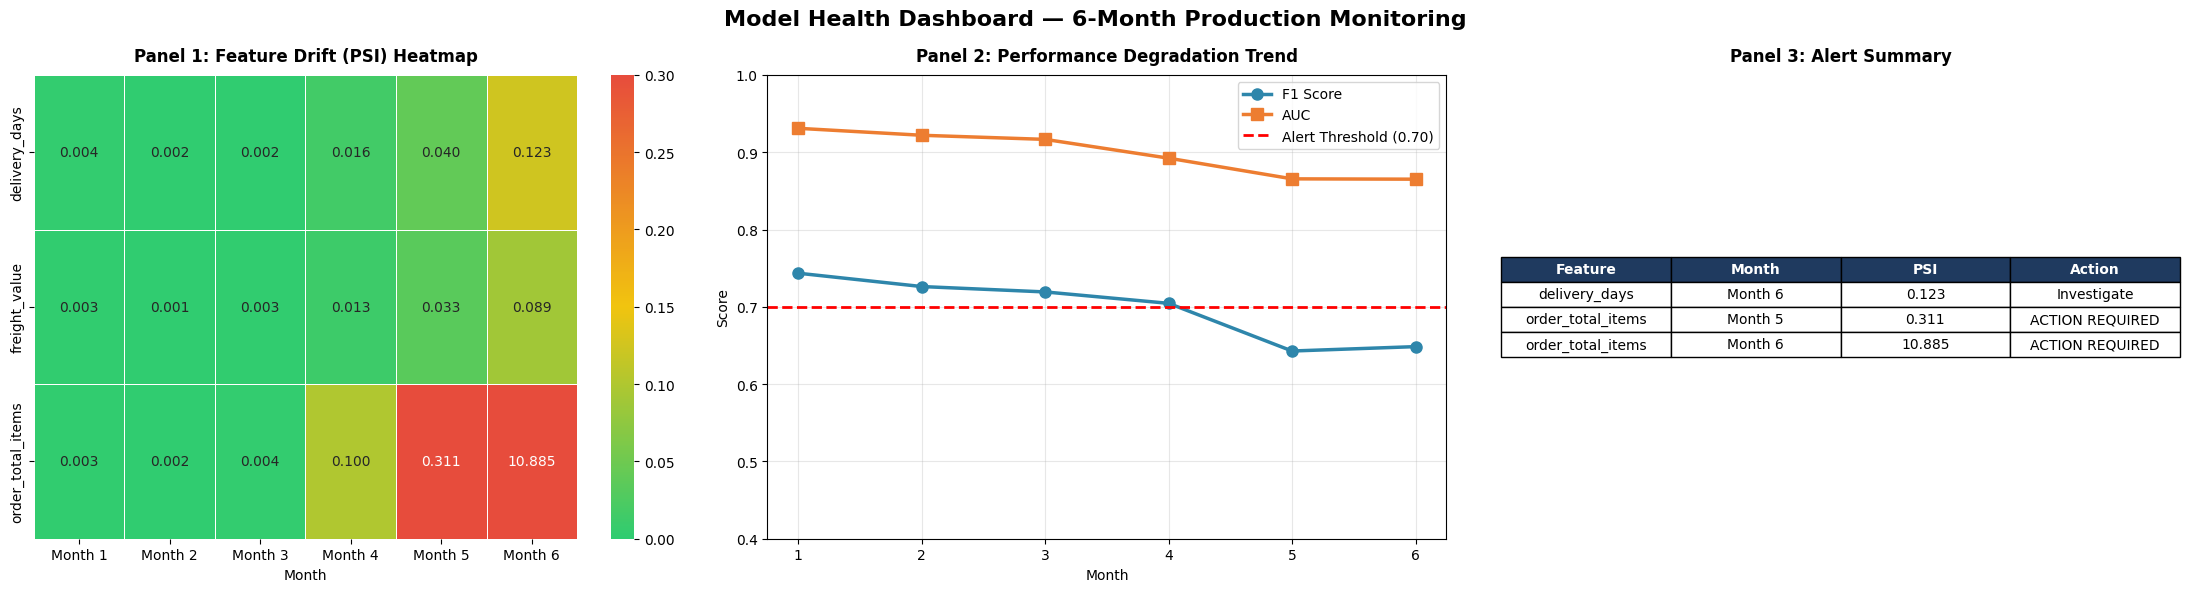

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# prepare data
alerts = []
for feature in test_features:
    for month in range(1, 7):
        psi_val = psi_results[feature][f"Month {month}"]
        if psi_val >= 0.2:
            alerts.append([feature, f"Month {month}", f"{psi_val:.3f}", "ACTION REQUIRED"])
        elif psi_val >= 0.1:
            alerts.append([feature, f"Month {month}", f"{psi_val:.3f}", "Investigate"])

# Create a single figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Model Health Dashboard — 6-Month Production Monitoring", fontsize=16, fontweight='bold')

# Panel 1: Drift Heatmap
colors = ['#2ecc71', '#f1c40f', '#e74c3c'] # Green, Yellow, Red
cmap = sns.blend_palette(colors, as_cmap=True)
sns.heatmap(psi_df, annot=True, fmt=".3f", cmap=cmap, vmin=0, vmax=0.3, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Panel 1: Feature Drift (PSI) Heatmap', fontweight='bold', pad=10)
axes[0].set_xlabel('Month')

# Panel 2: Performance Trend
axes[1].plot(metrics_df.index, metrics_df['F1'], 'o-', lw=2.5, ms=8, label='F1 Score', color='#2e86ab')
axes[1].plot(metrics_df.index, metrics_df['AUC'], 's-', lw=2.5, ms=8, label='AUC', color='#ed7d31')

# add red alert threshold line
axes[1].axhline(y=0.70, color='red', ls='--', lw=2, label='Alert Threshold (0.70)')
axes[1].set_title('Panel 2: Performance Degradation Trend', fontweight='bold', pad=10)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.4, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Alert Summary
axes[2].axis('off')
axes[2].set_title('Panel 3: Alert Summary', fontweight='bold', pad=10)

if alerts:
    col_labels = ['Feature', 'Month', 'PSI', 'Action']
    table = axes[2].table(cellText=alerts, colLabels=col_labels, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    # style the headers
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#1f3a5f')
        table[0, j].set_text_props(color='white', fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'No Alerts / Stable', ha='center', va='center', fontsize=14, color='green')

plt.tight_layout()
plt.show()


Yes, this model should be retrained in Month 4 or 5. The decreases in accuracy by Month 4 would be enough to investigate, and by Month 5, action is required to retrain the model. I would use a PSI of 0.20 for a given feature as a benchmark to retrigger training. In this case, this happened at Month 5 for order_total_items - this hypothetical example represents changing consumer behavior of consumers ordering more items in each order, necessitating that the model be retrained. Month 5 is also when the F1 Score dropped beneath the 0.7 threshold. I would monitor both these metrics and investigate and possibly retrain when either threshold is crossed. Moving forward, an automated retraining pipeline should be triggered whenever any core feature registers a PSI ≥ 0.15 (Moderate Drift) or if the F1 score experiences a 10% absolute drop from its initial baseline.